# Libraries Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

# DataSet Load

In [ ]:
df = pd.read_csv('digitalmarketing.csv')

df.shape
print(df['Authors'].value_counts())

Authors
[No author name available]                                                                19
Holder D., Fairlie R.                                                                      4
Reed D.                                                                                    4
Martin E.J.                                                                                4
Chaffey D.                                                                                 3
                                                                                          ..
Lemon A., Doll-Myers S.                                                                    1
Eigenraam A.W., Eelen J., van Lin A., Verlegh P.W.J.                                       1
Chen C., Kim S., Bui H., Rossi R., Koh E., Kveton B., Bunescu R.                           1
Liébana-Cabanillas F., Corral-Hermoso J.A., Villarejo-Ramos Á.F., Higueras-Castillo E.     1
Nahili W., Rezeg K.                                           

# Preprocessing

In [ ]:
target_col = 'Citation_Level (TARGET)'

member1_cols = ['Year', 'Volume', 'Issue', 'Art. No.', 'Page start',
                'Page end', 'Page count', 'Cited by', 'Publisher',
                'ISSN', 'ISBN', 'CODEN']

df_clean = df[member1_cols + [target_col]].copy()
feature_cols = member1_cols

for col in feature_cols:
    if df_clean[col].dtype in ['float64', 'int64']:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    else:
        df_clean[col] = df_clean[col].fillna('Unknown')
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(df_clean[target_col])
X = df_clean.drop(columns=[target_col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print(X_scaled.shape)
print(feature_cols)
print(le_target.classes_)

print("Missing values filled:\n", df[member1_cols].isnull().sum())
print("\nFinal shape:", X_scaled.shape)


(1023, 12)
['Year', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end', 'Page count', 'Cited by', 'Publisher', 'ISSN', 'ISBN', 'CODEN']
['High' 'Low' 'Medium' 'Not Cited']
Missing values filled:
 Year             0
Volume         241
Issue          419
Art. No.       875
Page start     145
Page end       152
Page count    1005
Cited by       483
Publisher      130
ISSN           230
ISBN           710
CODEN          941
dtype: int64

Final shape: (1023, 12)


# FEATURE SELECTION


📊 Information Gain Scores:
Cited by      0.9521
Publisher     0.1342
ISSN          0.1320
ISBN          0.0659
Volume        0.0550
Year          0.0417
Issue         0.0278
Page count    0.0199
Art. No.      0.0154
Page start    0.0124
Page end      0.0096
CODEN         0.0000


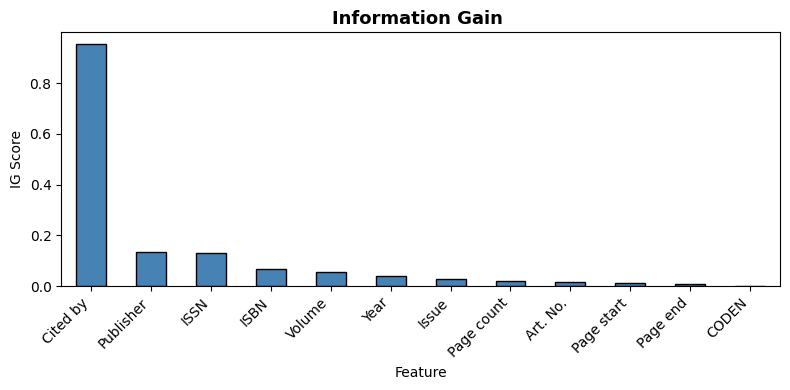


 Top 8 features selected: ['Cited by', 'Publisher', 'ISSN', 'ISBN', 'Volume', 'Year', 'Issue', 'Page count']
 New X shape after feature selection: (1023, 8)


In [ ]:
# FEATURE SELECTION — Information Gain

from sklearn.feature_selection import mutual_info_classif

ig_scores = mutual_info_classif(X_scaled, y, random_state=42)
ig_series = pd.Series(ig_scores, index=X.columns).sort_values(ascending=False)

print("📊 Information Gain Scores:")
print(ig_series.round(4).to_string())

plt.figure(figsize=(8, 4))
ig_series.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Information Gain ", fontsize=13, fontweight='bold')
plt.xlabel("Feature")
plt.ylabel("IG Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('LR_IG_features.png', dpi=150, bbox_inches='tight')
plt.show()

k = 8
top_features = ig_series.head(k).index.tolist()

top_features = ig_series.head(k).index.tolist()
print(f"\n Top {k} features selected: {top_features}")


X_scaled = pd.DataFrame(X_scaled, columns=X.columns)[top_features].values
print(f" New X shape after feature selection: {X_scaled.shape}")

# Target Distribution

/tmp/ipykernel_2075/639510753.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order, y=[counts[c] for c in order], palette='Set2', edgecolor='black')


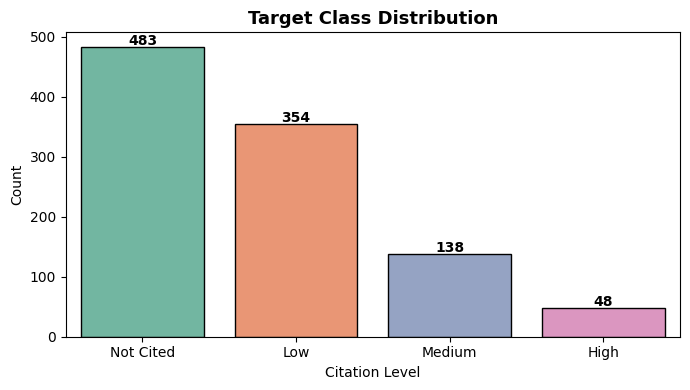

In [ ]:
plt.figure(figsize=(7, 4))
order = ['Not Cited', 'Low', 'Medium', 'High']
counts = df[target_col].value_counts()
sns.barplot(x=order, y=[counts[c] for c in order], palette='Set2', edgecolor='black')
plt.title("Target Class Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Citation Level")
plt.ylabel("Count")
for i, val in enumerate([counts[c] for c in order]):
    plt.text(i, val + 3, str(val), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Logistic Regression + 4 Splits


🔹 Split 1: 80/20 | Accuracy: 0.6780
              precision    recall  f1-score   support

        High       1.00      0.56      0.71         9
         Low       0.86      0.34      0.48        71
      Medium       0.81      0.61      0.69        28
   Not Cited       0.62      0.96      0.75        97

    accuracy                           0.68       205
   macro avg       0.82      0.61      0.66       205
weighted avg       0.74      0.68      0.65       205


🔹 Split 2: 70/30 | Accuracy: 0.6515
              precision    recall  f1-score   support

        High       1.00      0.71      0.83        14
         Low       0.70      0.33      0.45       106
      Medium       0.86      0.60      0.70        42
   Not Cited       0.60      0.90      0.72       145

    accuracy                           0.65       307
   macro avg       0.79      0.63      0.68       307
weighted avg       0.69      0.65      0.63       307


🔹 Split 3: 75/25 | Accuracy: 0.5898
              preci

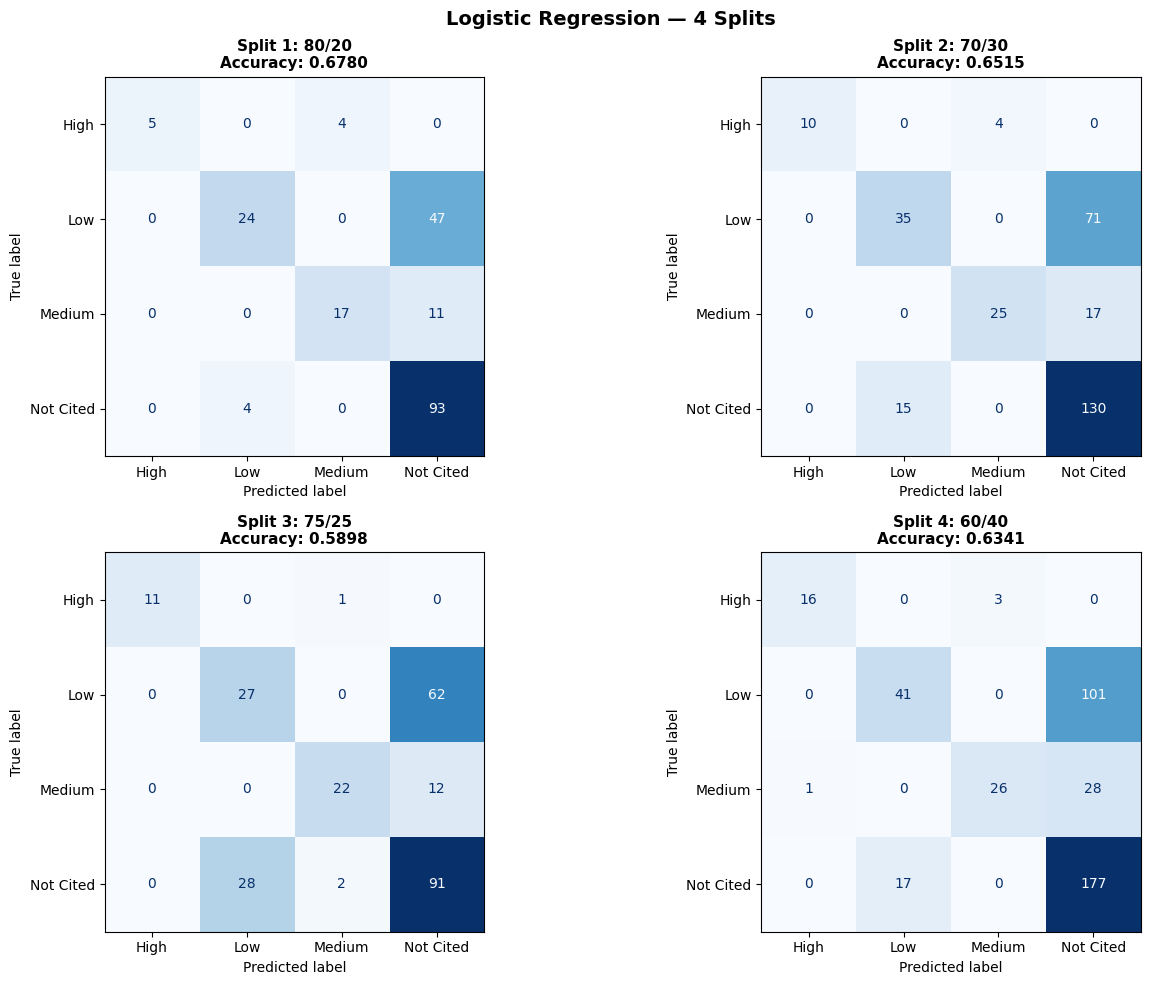

In [ ]:
splits = [(0.2, 42), (0.3, 42), (0.25, 0), (0.4, 99)]
lr_results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (test_size, rand_state) in enumerate(splits):
    label = f"Split {i+1}: {int((1-test_size)*100)}/{int(test_size*100)}"
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=rand_state, stratify=y
    )

    lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    lr_results.append({'Split': label, 'Train': len(X_train),
                       'Test': len(X_test), 'Accuracy': round(acc, 4)})

    print(f"\n{'='*50}")
    print(f"🔹 {label} | Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{label}\nAccuracy: {acc:.4f}", fontsize=11, fontweight='bold')

plt.suptitle("Logistic Regression — 4 Splits", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('LR_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Logistic Regression - Accuracy Comparison


📊 Summary:
         Split  Train  Test  Accuracy
Split 1: 80/20    818   205    0.6780
Split 2: 70/30    716   307    0.6515
Split 3: 75/25    767   256    0.5898
Split 4: 60/40    613   410    0.6341


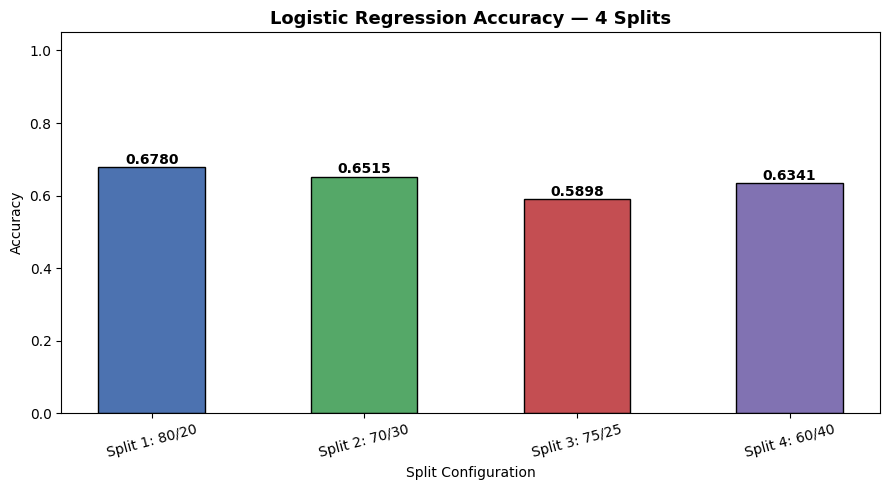

In [ ]:
lr_df = pd.DataFrame(lr_results)
print("\n📊 Summary:")
print(lr_df.to_string(index=False))

plt.figure(figsize=(9, 5))
bars = plt.bar(lr_df['Split'], lr_df['Accuracy'],
               color=['#4C72B0','#55A868','#C44E52','#8172B2'],
               edgecolor='black', width=0.5)
plt.ylim(0, 1.05)
plt.title("Logistic Regression Accuracy — 4 Splits", fontsize=13, fontweight='bold')
plt.xlabel("Split Configuration")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
for bar, acc in zip(bars, lr_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.4f}", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('LR_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# HeatMap

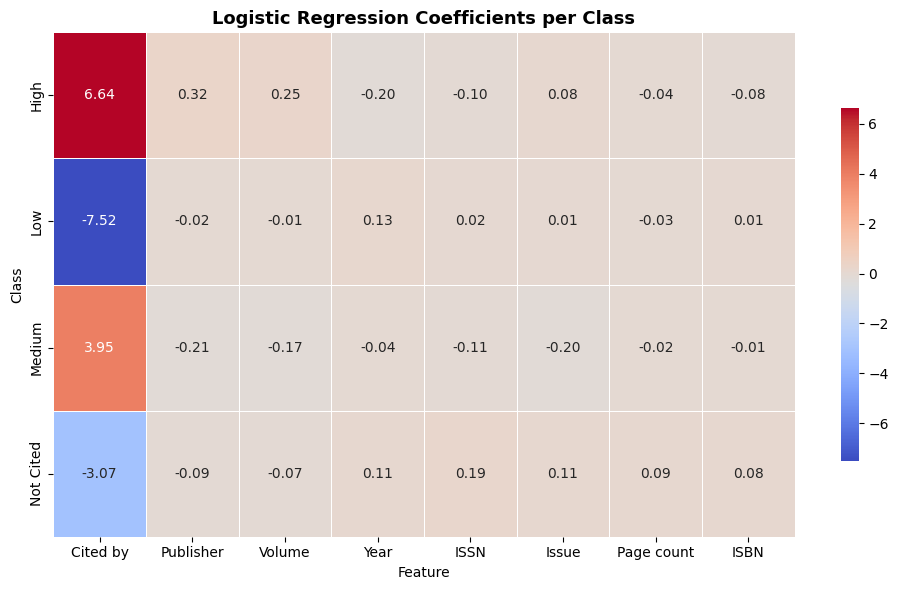

In [ ]:
# Feature Importance (Coefficients Heatmap)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
lr_best = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_best.fit(X_train, y_train)

coef_df = pd.DataFrame(
    lr_best.coef_,
    columns=top_features,
    index=le_target.classes_
).T

coef_df['mean_abs'] = coef_df.abs().mean(axis=1)
coef_df = coef_df.sort_values('mean_abs', ascending=False).drop(columns='mean_abs')

plt.figure(figsize=(10, 6))
sns.heatmap(coef_df.T, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={"shrink": 0.7})
plt.title("Logistic Regression Coefficients per Class", fontsize=13, fontweight='bold')
plt.xlabel("Feature")
plt.ylabel("Class")
plt.tight_layout()
plt.savefig('LR_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


📊 Evaluation Metrics — Logistic Regression
         Split  Accuracy  Precision  Recall  F1-Score
Split 1: 80/20    0.6780     0.7428  0.6780    0.6489
Split 2: 70/30    0.6515     0.6869  0.6515    0.6276
Split 3: 75/25    0.5898     0.5951  0.5898    0.5750
Split 4: 60/40    0.6341     0.6824  0.6341    0.6012


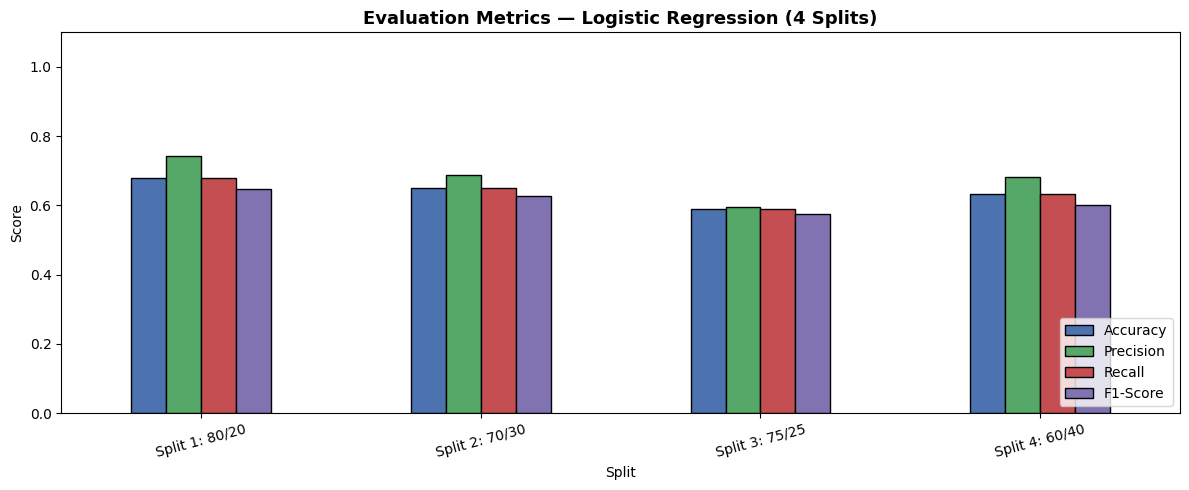

In [ ]:
# ============================================================
# CELL — Evaluation Metrics Table
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_results = []

for i, (test_size, rand_state) in enumerate(splits):
    label = f"Split {i+1}: {int((1-test_size)*100)}/{int(test_size*100)}"
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=rand_state, stratify=y
    )

    lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    metrics_results.append({
        'Split': label,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
    })

metrics_df = pd.DataFrame(metrics_results)
print("📊 Evaluation Metrics — Logistic Regression")
print(metrics_df.to_string(index=False))

# Plot
metrics_df.set_index('Split')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(12, 5), edgecolor='black',
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2']
)
plt.title("Evaluation Metrics — Logistic Regression (4 Splits)", fontsize=13, fontweight='bold')
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('LR_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Significance Testing (Paired t-test)

from scipy import stats

all_preds = []
all_tests = []

for test_size, rand_state in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=rand_state, stratify=y
    )
    lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    all_preds.append(y_pred)
    all_tests.append(y_test)

split_labels = ['Split1 80/20', 'Split2 70/30', 'Split3 75/25', 'Split4 60/40']

print(f"{'Comparison':<30} {'t-stat':>8} {'p-value':>10} {'Significant?':>14}")

for i in range(len(splits)):
    for j in range(i+1, len(splits)):

        min_len = min(len(all_tests[i]), len(all_tests[j]))
        correct_i = (all_preds[i][:min_len] == all_tests[i][:min_len]).astype(int)
        correct_j = (all_preds[j][:min_len] == all_tests[j][:min_len]).astype(int)

        t_stat, p_val = stats.ttest_rel(correct_i, correct_j)
        significant = "Yes" if p_val < 0.05 else "No"
        comparison = f"{split_labels[i]} vs {split_labels[j]}"
        print(f"{comparison:<30} {t_stat:>8.4f} {p_val:>10.4f} {significant:>14}")


Comparison                       t-stat    p-value   Significant?
Split1 80/20 vs Split2 70/30     0.2016     0.8405             No
Split1 80/20 vs Split3 75/25     1.9946     0.0474            Yes
Split1 80/20 vs Split4 60/40     1.5280     0.1281             No
Split2 70/30 vs Split3 75/25     1.6658     0.0970             No
Split2 70/30 vs Split4 60/40     0.7521     0.4526             No
Split3 75/25 vs Split4 60/40    -0.0879     0.9300             No
